In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys 

script_dir = os.path.dirname(__file__)

path = os.path.abspath(os.path.join(script_dir, 'simulations_ds'))
df = pd.read_csv(path + '/1000_hetero_ds')
df2 = pd.read_csv(path + '/1000_correlated_ds')
df3 = pd.read_csv(path + '/1000_normal_ds')


path2 = os.path.abspath(os.path.join(script_dir, os.pardir, os.pardir, os.pardir, 'final_LaTeX'))

print(path2)

NameError: name '__file__' is not defined

In [ ]:
df = df[['SC Score', 'RMSPE']]
df2 = df2[['SC Score', 'RMSPE']]
df3 = df3[['SC Score', 'RMSPE']]

df = df.rename(columns={'SC Score': 'hetero_sc', 'RMSPE': 'hetero_rmspe'})
df2 = df2.rename(columns={'SC Score': 'correlated_sc', 'RMSPE': 'correlated_rmspe'})
df3 = df3.rename(columns={'SC Score': 'normal_sc', 'RMSPE': 'normal_rmspe'})

In [ ]:
df = pd.concat([df, df2, df3], axis=1)
df.head()
df.columns

Index(['hetero_sc', 'hetero_rmspe', 'correlated_sc', 'correlated_rmspe',
       'normal_sc', 'normal_rmspe'],
      dtype='object')

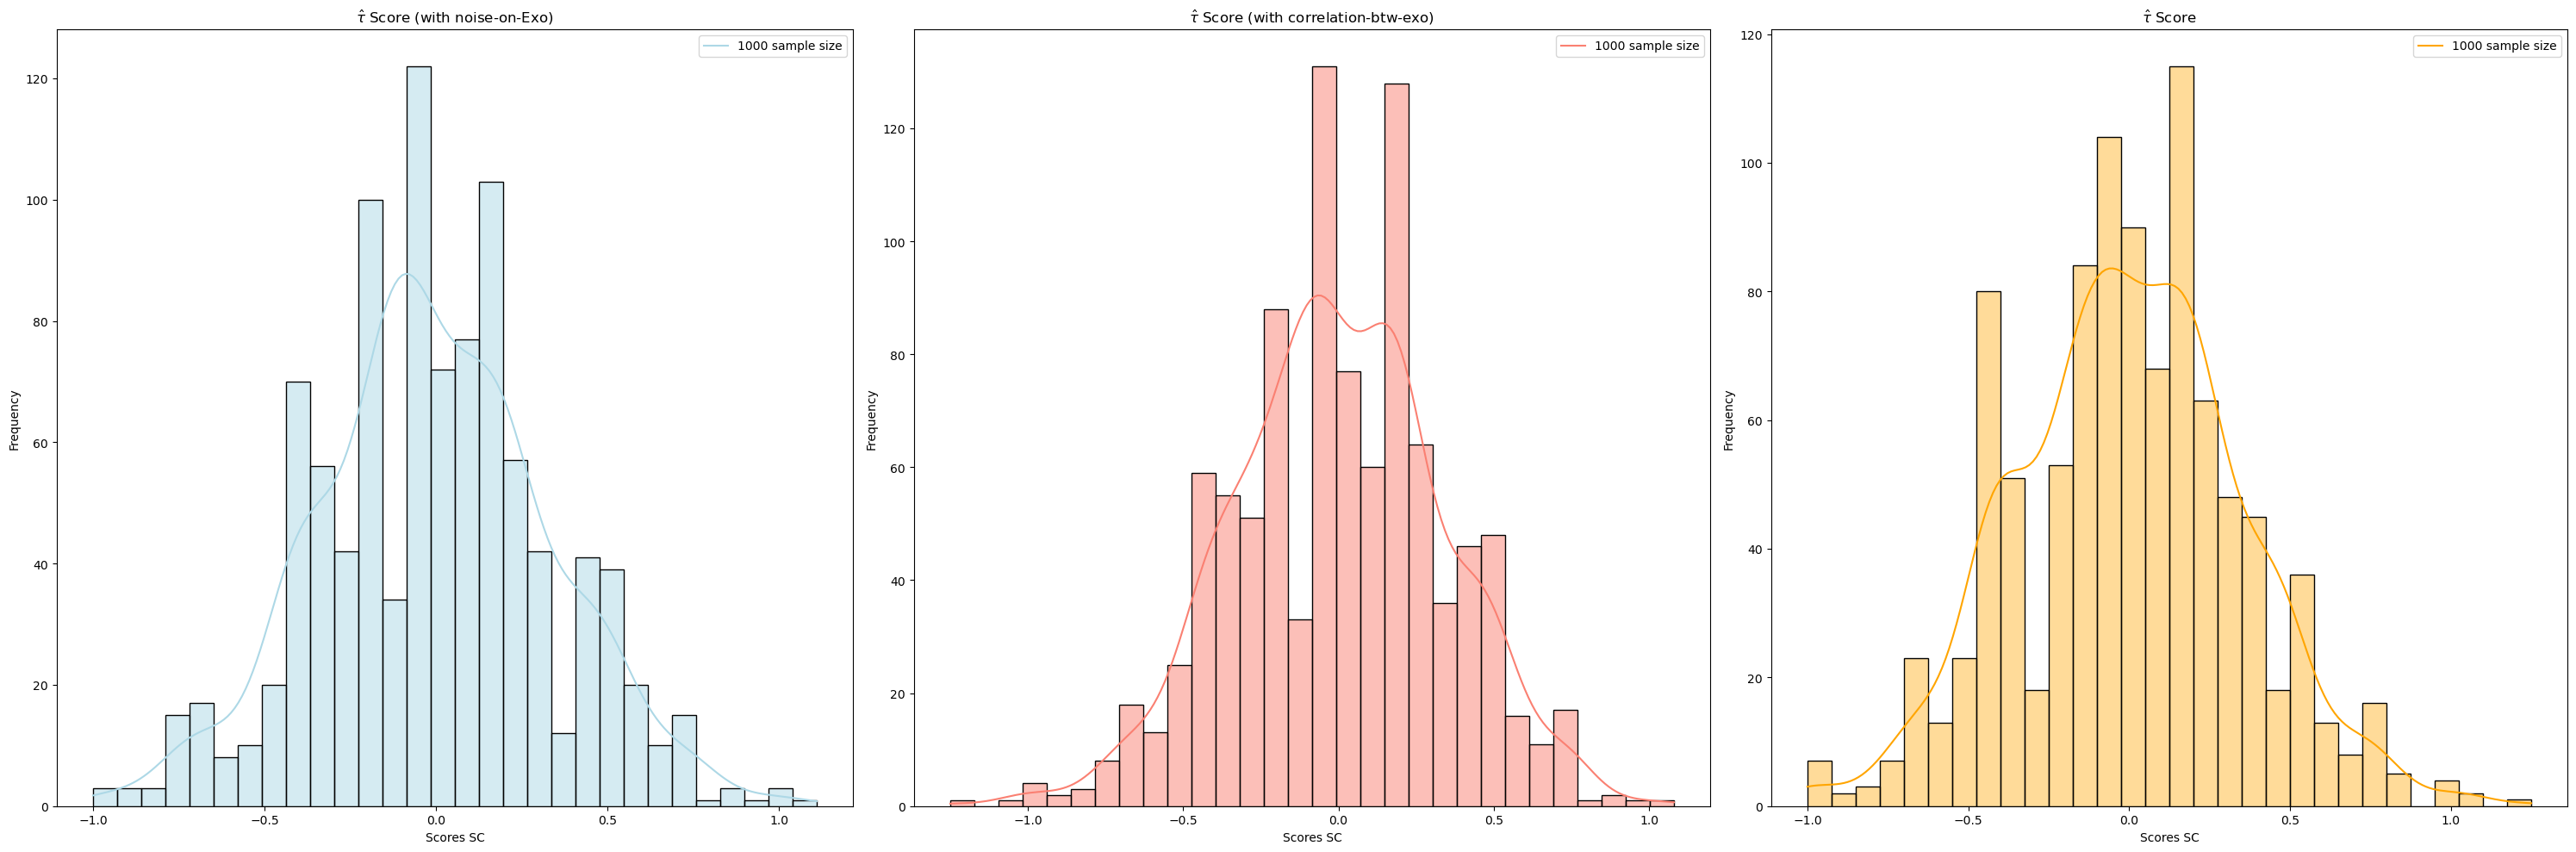

In [ ]:

# Tracer les distributions
plt.figure(figsize=(30, 10))

plt.subplot(1, 3, 1)
sns.histplot(df['hetero_sc'], kde=True, color='lightblue', bins=30)
plt.title(r'$\hat{\tau}$ Score (with noise-on-Exo)')
plt.xlabel('Scores SC')
plt.legend(['1000 sample size'])
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df['correlated_sc'], kde=True, color='salmon', bins=30)
plt.title(r'$\hat{\tau}$ Score (with correlation-btw-exo)')
plt.xlabel('Scores SC')
plt.legend(['1000 sample size'])
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df['normal_sc'], kde=True, color='orange', bins=30, alpha=0.4)
plt.title(r'$\hat{\tau}$ Score')
plt.xlabel('Scores SC')
plt.legend(['1000 sample size'])
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

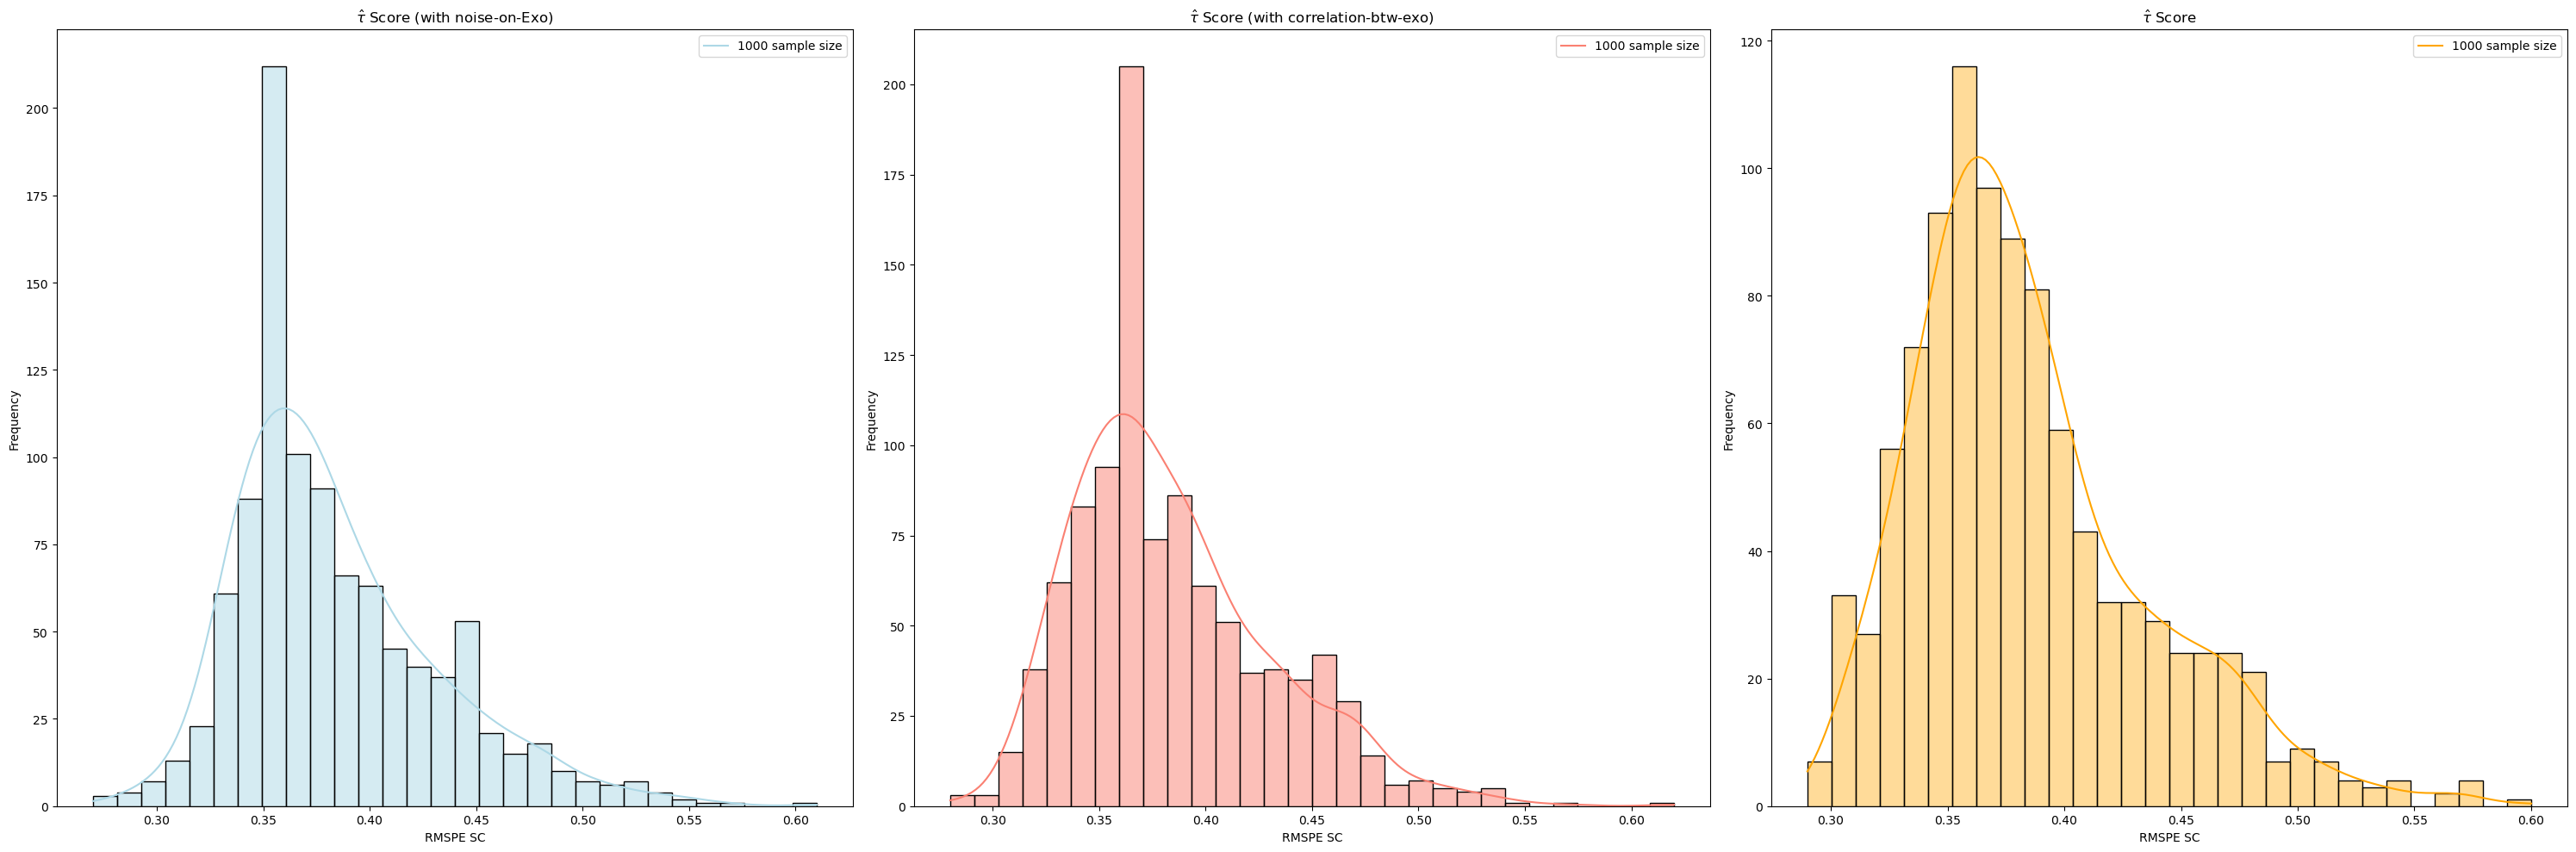

In [ ]:
plt.figure(figsize=(30, 10))

plt.subplot(1, 3, 1)
sns.histplot(df['hetero_rmspe'], kde=True, color='lightblue', bins=30)
plt.title(r'$\hat{\tau}$ Score (with noise-on-Exo)')
plt.xlabel('RMSPE SC')
plt.legend(['1000 sample size'])
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df['correlated_rmspe'], kde=True, color='salmon', bins=30)
plt.title(r'$\hat{\tau}$ Score (with correlation-btw-exo)')
plt.xlabel('RMSPE SC')
plt.legend(['1000 sample size'])
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df['normal_rmspe'], kde=True, color='orange', bins=30, alpha=0.4)
plt.title(r'$\hat{\tau}$ Score')
plt.xlabel('RMSPE SC')
plt.legend(['1000 sample size'])
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
s = df[['hetero_sc', 'correlated_sc', 'normal_sc']]
r = df[['hetero_rmspe', 'correlated_rmspe', 'normal_rmspe']]

s = s.rename(columns={'hetero_sc': 'noise', 'correlated_sc': 'correlation', 'normal_sc': 'normal'})
r = r.rename(columns={'hetero_rmspe': 'noise', 'correlated_rmspe': 'correlation', 'normal_rmspe': 'normal'})

r = r.describe()
s = s.describe()

r.loc['skew'] = r.skew()
r.loc['kurt'] = r.kurt()
r = r.T.round(2)

s.loc['skew'] = s.skew()
s.loc['kurt'] = s.kurt()
s = s.T.round(2)

# r.to_latex(path2 + 'rmspe.tex')
print(r)

              count  mean   std   min   25%   50%   75%   max  skew  kurt
noise        1000.0  0.38  0.05  0.27  0.35  0.37  0.41  0.61  2.83   9.0
correlation  1000.0  0.38  0.05  0.28  0.35  0.37  0.41  0.62  2.83   9.0
normal       1000.0  0.39  0.05  0.29  0.35  0.37  0.41  0.60  2.83   9.0


In [ ]:
# s.to_latex(path2 + 'sc.tex')
print(s)

              count  mean   std   min   25%   50%   75%   max  skew  kurt
noise        1000.0 -0.01  0.34 -1.00 -0.21 -0.02  0.18  1.11  2.83   9.0
correlation  1000.0 -0.00  0.34 -1.25 -0.22  0.00  0.21  1.08  2.83   9.0
normal       1000.0 -0.00  0.35 -1.00 -0.24 -0.00  0.23  1.25  2.83   9.0
